In [68]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from db_connection import db, Songs, SongAudioFeatures

# Import from CSV
Normally I would use the database, but I decided to use the CSV file for reproducibility.

In [69]:
df_csv = pd.read_csv("songs_export.csv", index_col="id_x")
df_csv.index = df_csv.index.astype(str)
df_csv.index.name = "song_id"

song_name_series = df_csv["song_name"]
artist_series = df_csv["artists"]

audio_col_map = {
    "acousticness": "acousticness",
    "danceability": "danceability",
    "energy": "energy",
    "instrumentalness": "instrumentalness",
    "key": "key",
    "liveness": "liveness",
    "loudness": "loudness",
    "mode": "mode",
    "speechiness": "speechiness",
    "tempo": "tempo",
    "time_signature": "time_signature",
    "valence": "valence",
    "num_samples": "num_samples",
    "duration": "duration",
    "duration_ms": "duration_ms_y",
    "end_of_fade_in": "end_of_fade_in",
    "start_of_fade_out": "start_of_fade_out",
    "tempo_confidence": "tempo_confidence",
    "time_signature_confidence": "time_signature_confidence",
    "key_confidence": "key_confidence",
    "mode_confidence": "mode_confidence",
}
df_audio = df_csv[list(audio_col_map.values())].rename(columns={v: k for k, v in audio_col_map.items()})
df_audio["song_duration_ms"] = df_csv["duration_ms_x"]
df_audio["popularity"] = df_csv["popularity"]
df_audio["explicit"] = df_csv["explicit"].apply(lambda x: int(x) if pd.notna(x) else None)

def parse_embedding(s):
    if pd.isna(s):
        return [np.nan] * 768
    cleaned = " ".join(s.strip("[] \n").split())
    return np.fromstring(cleaned, sep=" ").tolist()

lyrics_emb_columns = [f"lyrics_emb_{i}" for i in range(768)]
lyrics_parsed = df_csv["lyrics_embeddings"].apply(parse_embedding)
df_lyrics_emb = pd.DataFrame(lyrics_parsed.tolist(), index=df_csv.index, columns=lyrics_emb_columns)
df_lyrics_emb.index.name = "song_id"

image_emb_columns = [f"image_emb_{i}" for i in range(768)]
image_parsed = df_csv["image_embeddings"].apply(parse_embedding)
df_image_emb = pd.DataFrame(image_parsed.tolist(), index=df_csv.index, columns=image_emb_columns)
df_image_emb.index.name = "song_id"

print(f"df_audio: {df_audio.shape}")
print(f"df_lyrics_emb: {df_lyrics_emb.shape}")
print(f"df_image_emb: {df_image_emb.shape}")

df_audio: (100, 24)
df_lyrics_emb: (100, 768)
df_image_emb: (100, 768)


In [70]:
df_audio.to_csv("songs_export_audio_features.csv")
df_lyrics_emb.to_csv("songs_export_lyrics_embeddings.csv")
df_image_emb.to_csv("songs_export_image_embeddings.csv")

# Euclidean Distance & Normalization
I normalize the data since not all features are on the same scale. Then I computed the euclidean distance between each song.

In [71]:
def euclidean_distance_matrix(df: pd.DataFrame) -> pd.DataFrame:
    filled = df.fillna(df.median())
    dist_vec = pdist(filled.values, metric="euclidean")
    dist_mat = squareform(dist_vec)
    np.fill_diagonal(dist_mat, np.nan)
    return pd.DataFrame(dist_mat, index=df.index, columns=df.index)
def normalize_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.dropna(axis=1, how="all")
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df)
    return pd.DataFrame(scaled, index=df.index, columns=df.columns)

df_audio_norm = normalize_df(df_audio)
df_lyrics_norm = normalize_df(df_lyrics_emb)
df_image_norm = normalize_df(df_image_emb)
dist_audio = euclidean_distance_matrix(df_audio_norm)
dist_lyrics = euclidean_distance_matrix(df_lyrics_norm)
dist_image = euclidean_distance_matrix(df_image_norm)

In [72]:
for label, raw, normed, dist in [
        ("Audio Features", df_audio, df_audio_norm, dist_audio),
        ("Lyrics Embeddings", df_lyrics_emb, df_lyrics_norm, dist_lyrics),
        ("Image Embeddings", df_image_emb, df_image_norm, dist_image),
    ]:
    print(f"{label}:")
    print(f"  Raw shape:        {raw.shape}")
    print(f"  Normalized range: {normed.min().min():.4f} to {normed.max().max():.4f}")
    print(f"  Distance matrix:  {dist.shape}")
    print(f"  Mean distance:    {dist.values[np.triu_indices_from(dist.values, k=1)].mean():.4f}")
    print()

Audio Features:
  Raw shape:        (100, 24)
  Normalized range: 0.0000 to 1.0000
  Distance matrix:  (100, 100)
  Mean distance:    1.7597

Lyrics Embeddings:
  Raw shape:        (100, 768)
  Normalized range: 0.0000 to 1.0000
  Distance matrix:  (100, 100)
  Mean distance:    5.4999

Image Embeddings:
  Raw shape:        (100, 768)
  Normalized range: 0.0000 to 1.0000
  Distance matrix:  (100, 100)
  Mean distance:    8.5255



# Expermenting
Here I experiment with the data. Feel free to skip ahead to the Keys and tempo section, where I answer the assignment's questions.

# K Means Clustering
I'm using K means clustering to group songs based on their features because it's simple and the same methods used in the example. Normally I would use a better method like hierarchical clustering or DBSCAN in a production environment.

In [73]:
def kmeans_cluster(df: pd.DataFrame, n_clusters: int, random_state: int = 42) -> pd.Series:
    filled = df.fillna(df.median())
    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state)
    labels = km.fit_predict(filled.values)
    return pd.Series(labels, index=df.index, name="cluster"), km

# N Clusters
You might be wondering why I chose 2 clusters. I decided through trial and error that this was a good number of clusters to use. Typically I would use a silhouette score to determine the optimal number of clusters, but since we haven't covered that in class yet, I went with 2.

In [74]:
clusters = 2

audio_clusters, audio_km = kmeans_cluster(df_audio_norm, n_clusters=clusters)
lyrics_clusters, lyrics_km = kmeans_cluster(df_lyrics_norm, n_clusters=clusters)
image_clusters, image_km = kmeans_cluster(df_image_norm, n_clusters=clusters)

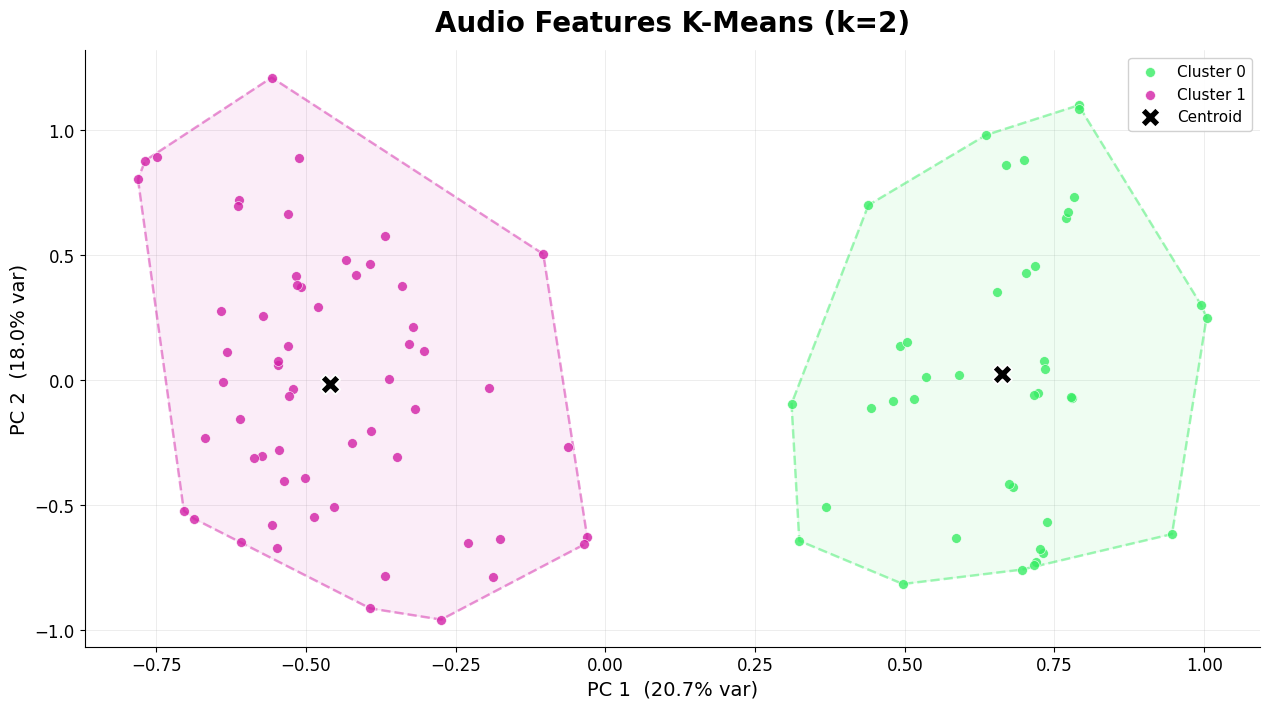

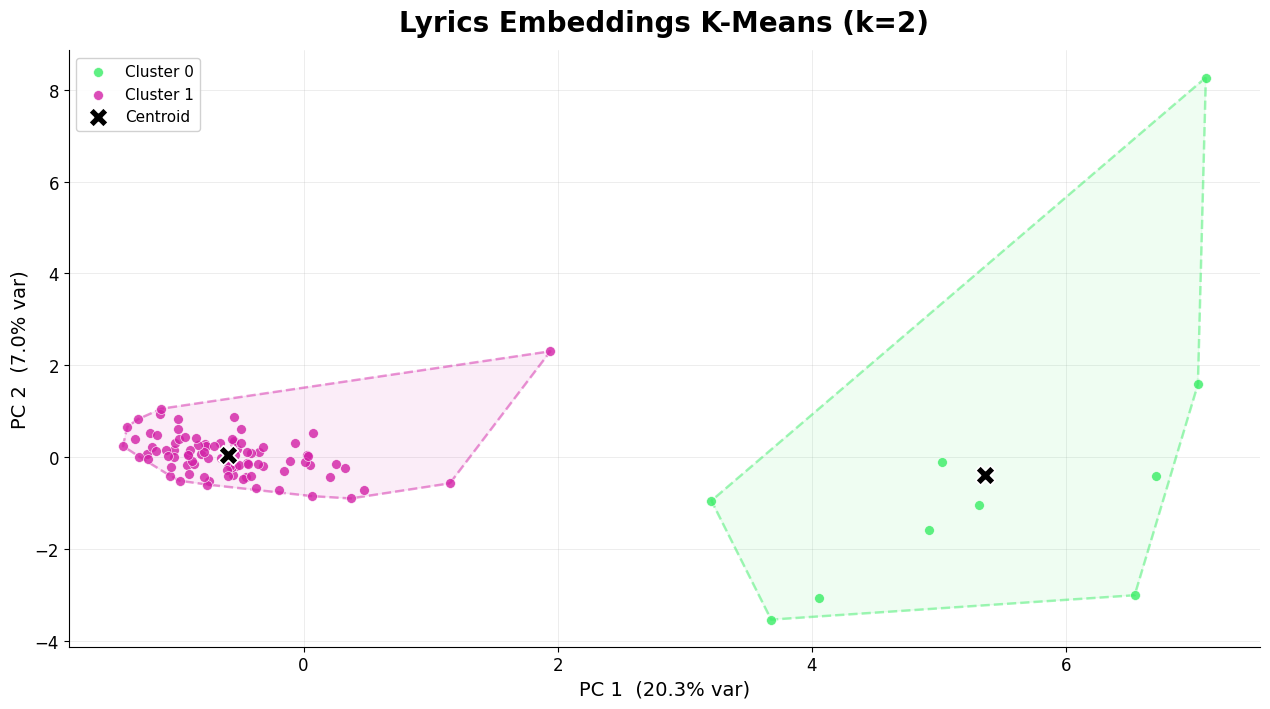

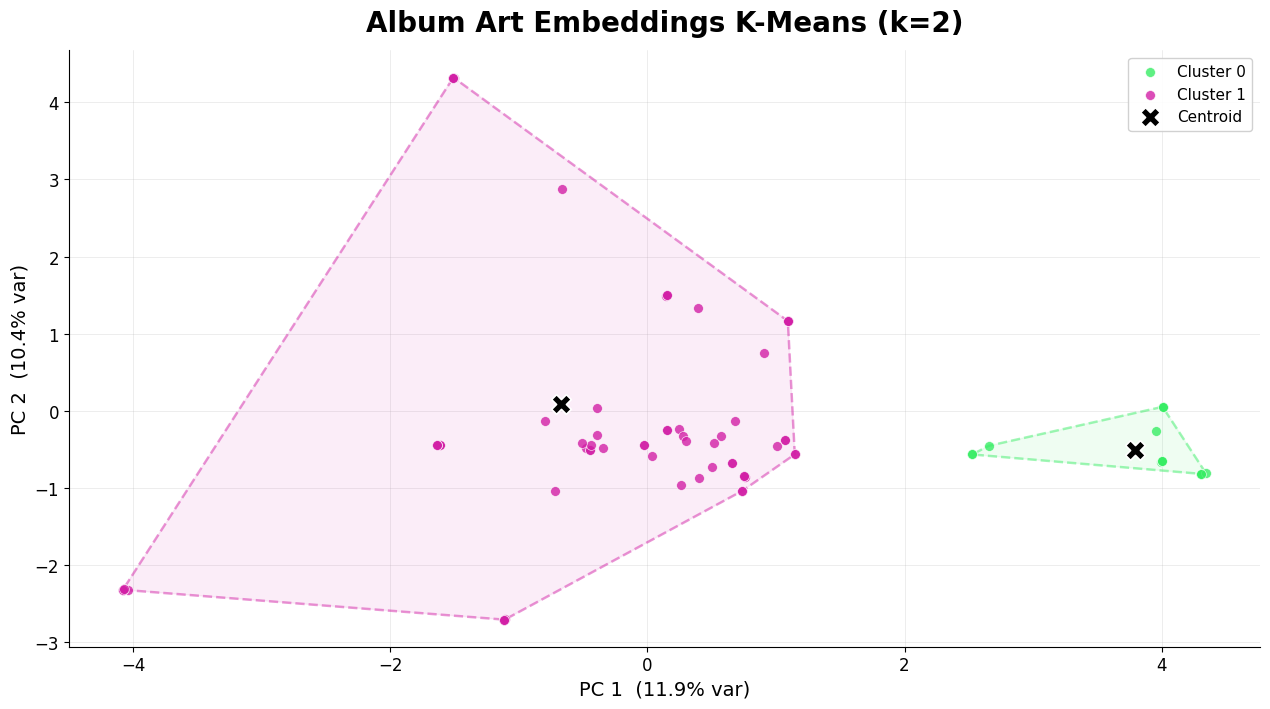

In [75]:
from graphing_graphics import plot_clusters_2d

# 1920x1080 at 150 DPI = 12.8 x 7.2 inches
W, H, DPI = 1920 / 150, 1080 / 150, 150

for df_norm, clust, km, title, fname in [
    (df_audio_norm,  audio_clusters,  audio_km,  "Audio Features K-Means (k={})".format(clusters),  "cluster_audio.png"),
    (df_lyrics_norm, lyrics_clusters, lyrics_km, "Lyrics Embeddings K-Means (k={})".format(clusters), "cluster_lyrics.png"),
    (df_image_norm,  image_clusters,  image_km,  "Album Art Embeddings K-Means (k={})".format(clusters), "cluster_image.png"),
]:
    fig, ax = plt.subplots(figsize=(W, H))
    plot_clusters_2d(df_norm, clust, km, title, ax)
    fig.tight_layout()
    fig.savefig(fname, dpi=DPI, bbox_inches="tight")
    plt.show()

# Merging Features
Although its cool for us humans to see this data seprately, its much easier for the computer to process if we merge them into one dataset. However, there is one caviat. Not all data features are created equal, although the symantic meaning of the cover is important, the audio features are much more important for a playlist to flow well. 

In [76]:
matrices = [dist_audio, dist_lyrics, dist_image]
weights = [0.7, 0.6, 0.3]

weights = np.array(weights) / np.sum(weights)
scaled = []
for mat in matrices:
    vals = mat.values
    lo, hi = np.nanmin(vals), np.nanmax(vals)
    if hi - lo > 0:
        scaled.append((vals - lo) / (hi - lo))
    else:
        scaled.append(np.zeros_like(vals))
merged_vals = sum(w * s for w, s in zip(weights, scaled))
np.fill_diagonal(merged_vals, np.nan)
dist_merged = pd.DataFrame(merged_vals, index=matrices[0].index, columns=matrices[0].columns)

weighted = [df * w for df, w in zip(matrices, weights)]
merged_features =  pd.concat(weighted, axis=1)

merged_clusters, merged_km = kmeans_cluster(merged_features, n_clusters=clusters)

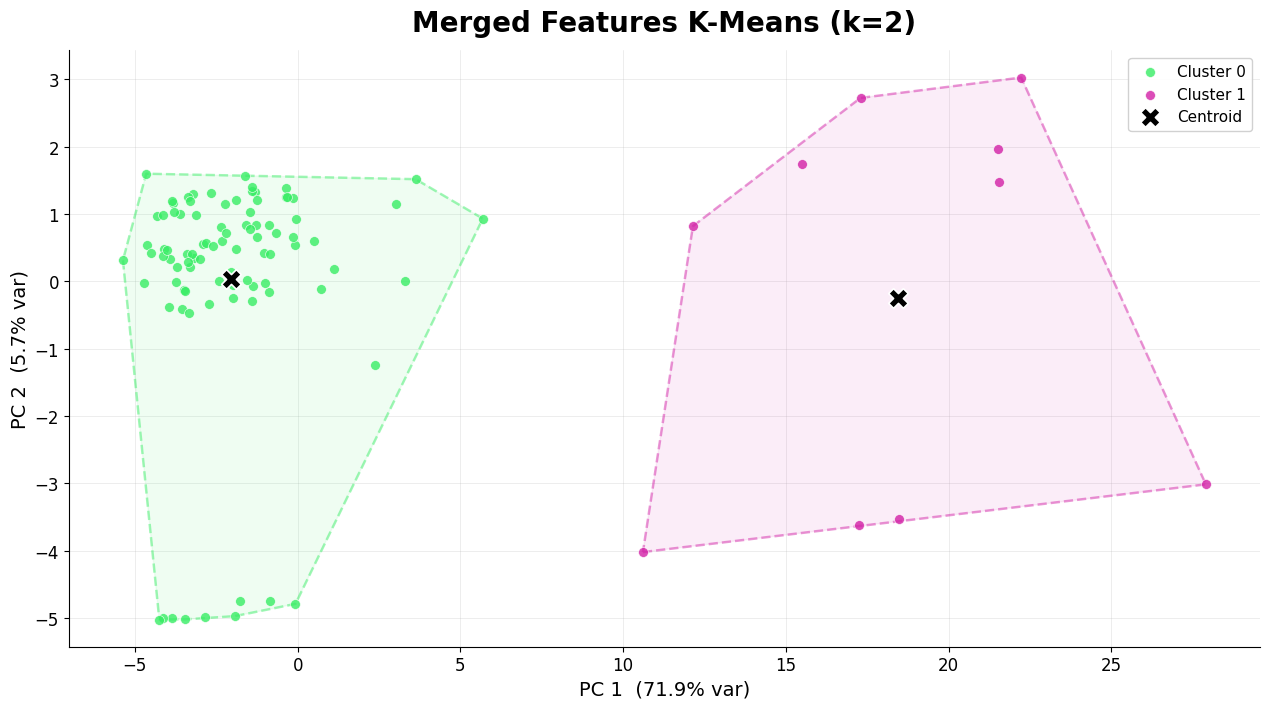

In [77]:
from graphing_graphics import plot_clusters_2d

# 1920x1080 at 150 DPI = 12.8 x 7.2 inches
W, H, DPI = 1920 / 150, 1080 / 150, 150

fig, ax = plt.subplots(figsize=(W, H))
plot_clusters_2d(merged_features, merged_clusters, merged_km, "Merged Features K-Means (k={})".format(clusters), ax)
fig.tight_layout()
fig.savefig("cluster_merged.png", dpi=DPI, bbox_inches="tight")
plt.show()

### Experimenting complete, now for the assignment.

# Keys & Tempo
After talking with my friend who DJs, I realized that one of the most important features to transition between songs is the key and tempo. This can quickly get complicated, but keys boil down to a circle of fifths (C to G is closer than C to F#), using this we can calculate the distance between keys. For tempos, we can use the BPM diffrence since songs that are close in tempo are more likely to be smooth transitions (ex. 160 BPM to 162 BPM will flow much better than 160 BPM to 180 BPM). With these two features, once normailzed we can use it as an additional metric to calculate the distance between songs.

In [78]:
circle_of_fifths = {0:0, 7:1, 2:2, 9:3, 4:4, 11:5, 6:6, 1:7, 8:8, 3:9, 10:10, 5:11}

keys = df_audio["key"].fillna(0).astype(int).values
n = len(keys)

key_pos = np.array([circle_of_fifths.get(k, 0) for k in keys])
key_diff = np.abs(key_pos[:, None] - key_pos[None, :])
key_dist = np.minimum(key_diff, 12 - key_diff) / 6.0

tempos = df_audio_norm["tempo"].values
tempo_dist = np.abs(tempos[:, None] - tempos[None, :])
flow_vals = 0.6 * key_dist + 0.4 * tempo_dist
np.fill_diagonal(flow_vals, np.nan)
dist_flow = pd.DataFrame(flow_vals, index=df_audio.index, columns=df_audio.index)

m = dist_merged.values
m_lo, m_hi = np.nanmin(m), np.nanmax(m)
m_scaled = (m - m_lo) / (m_hi - m_lo)
blended = 0.5 * flow_vals + 0.5 * m_scaled
np.fill_diagonal(blended, np.nan)
dist_playlist = pd.DataFrame(blended, index=df_audio.index, columns=df_audio.index)

print(f"Distance Flow  mean: {np.nanmean(dist_flow.values):.4f}")
print(f"Distance Merged mean: {np.nanmean(dist_merged.values):.4f}")
print(f"Distance Playlist mean: {np.nanmean(dist_playlist.values):.4f}")

Distance Flow  mean: 0.3240
Distance Merged mean: 0.5289
Distance Playlist mean: 0.4595


# The smooth playlist

This playlist building method greedily picks a song and then tries to find the closest song that satisfies the constraints.

The constraints are:
- No back-to-back repeats
- No more than 2 songs by the same artist
- No more than 2 songs from the same album

My algorithm works like this:
1. Picks the most central song (lowest average distance to all others).
2. Finds the next closest avaible song that satifies the constraints using the euclidean distances.
   To allow for more variation, amoung artists and albums:
      - I incresed the distance by 0.15 for each artist and album that was already in the playlist.
      - Every 2 steps, I blend 75% flow-closeness with 25% semantic distance to push the listener toward different moods/artists.
   
   If there is a tie on the closest distance between songs, I pick the one whose name comes first alphabetically.
3. After step 2 gets us 6 songs, I optimize the ordering to reduce the total distance to be as small as possible.

In [79]:
avg_dist = dist_playlist.mean(axis=1)
start_song = avg_dist.idxmin()
playlist = [start_song]
selected = {start_song}
artist_penalty_weight = 0.15
variance_every = 2
variance_strength = 0.25
max_variance_flow = 0.25

for step in range(1, 6):
    current = playlist[-1]
    current_artist = artist_series[current]
    distances = dist_playlist.loc[current].copy()

    for sid in selected:
        distances[sid] = np.inf

    for sid in artist_series[artist_series == current_artist].index:
        if sid not in selected:
            distances[sid] = np.inf

    artist_counts = {}
    for sid in playlist:
        a = artist_series[sid]
        artist_counts[a] = artist_counts.get(a, 0) + 1
    for sid in distances.index:
        if distances[sid] < np.inf:
            a = artist_series[sid]
            if a in artist_counts:
                distances[sid] += artist_penalty_weight * artist_counts[a]

    if distances.min() == np.inf:
        distances = dist_playlist.loc[current].copy()
        for sid in selected:
            distances[sid] = np.inf

    if step % variance_every == 0 and distances.min() < max_variance_flow:
        candidates = distances[distances < np.inf].index.tolist()
        if len(candidates) > 1:
            flow_vals_step = distances[candidates].values
            f_min, f_max = flow_vals_step.min(), flow_vals_step.max()
            flow_norm = (flow_vals_step - f_min) / (f_max - f_min) if f_max > f_min else np.zeros(len(candidates))
            flow_closeness = 1.0 - flow_norm

            sem_vals = dist_merged.loc[current, candidates].values
            s_min, s_max = sem_vals.min(), sem_vals.max()
            sem_norm = (sem_vals - s_min) / (s_max - s_min) if s_max > s_min else np.zeros(len(candidates))

            score = (1 - variance_strength) * flow_closeness + variance_strength * sem_norm
            next_song = candidates[np.argmax(score)]
        else:
            min_dist = distances.min()
            tied = distances[distances == min_dist].index.tolist()
            tied.sort(key=lambda s: song_name_series[s].lower())
            next_song = tied[0]
    else:
        min_dist = distances.min()
        tied = distances[distances == min_dist].index.tolist()
        tied.sort(key=lambda s: song_name_series[s].lower())
        next_song = tied[0]

    playlist.append(next_song)
    selected.add(next_song)

for i, sid in enumerate(playlist):
    print(f"  S{i}: {song_name_series[sid]} by {artist_series[sid]}")

  S0: King Of My Heart by ['Taylor Swift']
  S1: Happier by ['Ed Sheeran']
  S2: Roller Coaster by ['Luke Bryan']
  S3: Growing Up (feat. Ed Sheeran) by ['Macklemore & Ryan Lewis', 'Macklemore', 'Ryan Lewis', 'Ed Sheeran']
  S4: Before I Let Go - Homecoming Live Bonus Track by ['Beyoncé']
  S5: River (feat. Ed Sheeran) by ['Eminem', 'Ed Sheeran']


# Question 1's Solution
The playlist of songs with the computed distances to make a smooth transition

In [80]:
route = list(playlist)
n = len(route)
improved = True
iters = 0
while improved and iters < 50:
    improved = False
    iters += 1
    for i in range(n - 2):
        for j in range(i + 2, n):
            old_cost = dist_playlist.loc[route[i], route[i + 1]]
            if j + 1 < n:
                old_cost += dist_playlist.loc[route[j], route[j + 1]]
            new_cost = dist_playlist.loc[route[i], route[j]]
            if j + 1 < n:
                new_cost += dist_playlist.loc[route[i + 1], route[j + 1]]
            if new_cost < old_cost - 1e-9:
                candidate = route[:i+1] + route[i+1:j+1][::-1] + route[j+1:]
                artist_ok = all(artist_series[candidate[k]] != artist_series[candidate[k+1]] for k in range(len(candidate)-1))
                if artist_ok:
                    route = candidate
                    improved = True
playlist = route


features = df_audio_norm.columns.tolist()
rows = []
for i, sid in enumerate(playlist):
    row = {"Song": song_name_series[sid], "Artist": artist_series[sid]}
    for f in features:
        row[f] = f"{df_audio_norm.loc[sid, f]:.3f}"
    if i > 0:
        prev = playlist[i-1]
        row["Flow Dist"] = f"{dist_flow.loc[prev, sid]:.4f}"
        row["Audio Dist"] = f"{dist_audio.loc[prev, sid]:.4f}"
        row["Lyrics Dist"] = f"{dist_lyrics.loc[prev, sid]:.4f}"
        row["Image Dist"] = f"{dist_image.loc[prev, sid]:.4f}"
        row["Merged Dist"] = f"{dist_merged.loc[prev, sid]:.4f}"
        row["Blended Dist"] = f"{dist_playlist.loc[prev, sid]:.4f}"
    else:
        row["Flow Dist"] = "-"
        row["Audio Dist"] = "-"
        row["Lyrics Dist"] = "-"
        row["Image Dist"] = "-"
        row["Merged Dist"] = "-"
        row["Blended Dist"] = "-"
    rows.append(row)

display(pd.DataFrame(rows))

,Song,Artist,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,...,mode_confidence,song_duration_ms,popularity,explicit,Flow Dist,Audio Dist,Lyrics Dist,Image Dist,Merged Dist,Blended Dist
0,King Of My Heart,['Taylor Swift'],0.427,0.709,0.871,0.518,0.900,0.752,0.737,0.000,...,0.562,0.265,0.673,0.000,-,-,-,-,-,-
1,Happier,['Ed Sheeran'],0.389,0.732,0.950,0.580,0.900,0.632,0.771,0.000,...,0.750,0.236,0.727,0.000,0.0000,0.6232,3.8817,8.0486,0.3090,0.1535
2,Roller Coaster,['Luke Bryan'],0.599,0.709,0.582,0.448,0.900,0.752,0.363,0.000,...,0.500,0.450,0.564,0.000,0.0000,0.9492,5.0461,9.5412,0.4148,0.2228
3,Growing Up (feat. Ed Sheeran),"['Macklemore & Ryan Lewis', 'Macklemore', 'Rya...",0.212,0.863,0.731,0.736,0.900,0.247,0.829,0.000,...,0.625,0.641,0.327,0.000,0.0373,1.0033,4.1310,9.5632,0.3971,0.2298
4,Before I Let Go - Homecoming Live Bonus Track,['Beyoncé'],0.152,0.853,0.915,0.671,0.900,0.331,0.546,0.000,...,0.688,0.374,0.382,1.000,0.0000,1.2164,3.8894,9.0595,0.4128,0.2215
5,River (feat. Ed Sheeran),"['Eminem', 'Ed Sheeran']",0.074,0.936,0.801,0.799,0.900,0.098,0.685,0.000,...,0.500,0.292,0.691,1.000,0.0210,0.5758,4.2871,9.0869,0.3311,0.1785


# Stats
This are the metrics that I'll use to evaluate the quality of the playlist

In [81]:
consec = list(range(len(playlist) - 1))
flow_d = [dist_flow.loc[playlist[i], playlist[i+1]] for i in consec]
audio_d = [dist_audio.loc[playlist[i], playlist[i+1]] for i in consec]
lyrics_d = [dist_lyrics.loc[playlist[i], playlist[i+1]] for i in consec]
image_d = [dist_image.loc[playlist[i], playlist[i+1]] for i in consec]
merged_d = [dist_merged.loc[playlist[i], playlist[i+1]] for i in consec]
blended_d = [dist_playlist.loc[playlist[i], playlist[i+1]] for i in consec]

from itertools import combinations

all_pairs_merged = [dist_merged.loc[a, b] for a, b in combinations(playlist, 2)]
unique_artists = list(set(artist_series[sid] for sid in playlist))

print(f"Mean distances:")
print(f"  Flow:    {np.mean(flow_d):.4f}  (deviation: {np.std(flow_d):.4f}, max: {max(flow_d):.4f})")
print(f"  Audio:   {np.mean(audio_d):.4f}  (deviation: {np.std(audio_d):.4f})")
print(f"  Lyrics:  {np.mean(lyrics_d):.4f}  (deviation: {np.std(lyrics_d):.4f})")
print(f"  Image:   {np.mean(image_d):.4f}  (deviation: {np.std(image_d):.4f})")
print(f"  Merged:  {np.mean(merged_d):.4f}  (deviation: {np.std(merged_d):.4f})")
print(f"  Blended: {np.mean(blended_d):.4f}  (deviation: {np.std(blended_d):.4f})")
print(f"Semantic spread: {np.mean(all_pairs_merged):.4f}")
print(f"Artist diversity: {len(unique_artists)} unique")

Mean distances:
  Flow:    0.0116  (deviation: 0.0152, max: 0.0373)
  Audio:   0.8736  (deviation: 0.2414)
  Lyrics:  4.2471  (deviation: 0.4278)
  Image:   9.0599  (deviation: 0.5493)
  Merged:  0.3730  (deviation: 0.0442)
  Blended: 0.2012  (deviation: 0.0300)
Semantic spread: 0.4042
Artist diversity: 6 unique


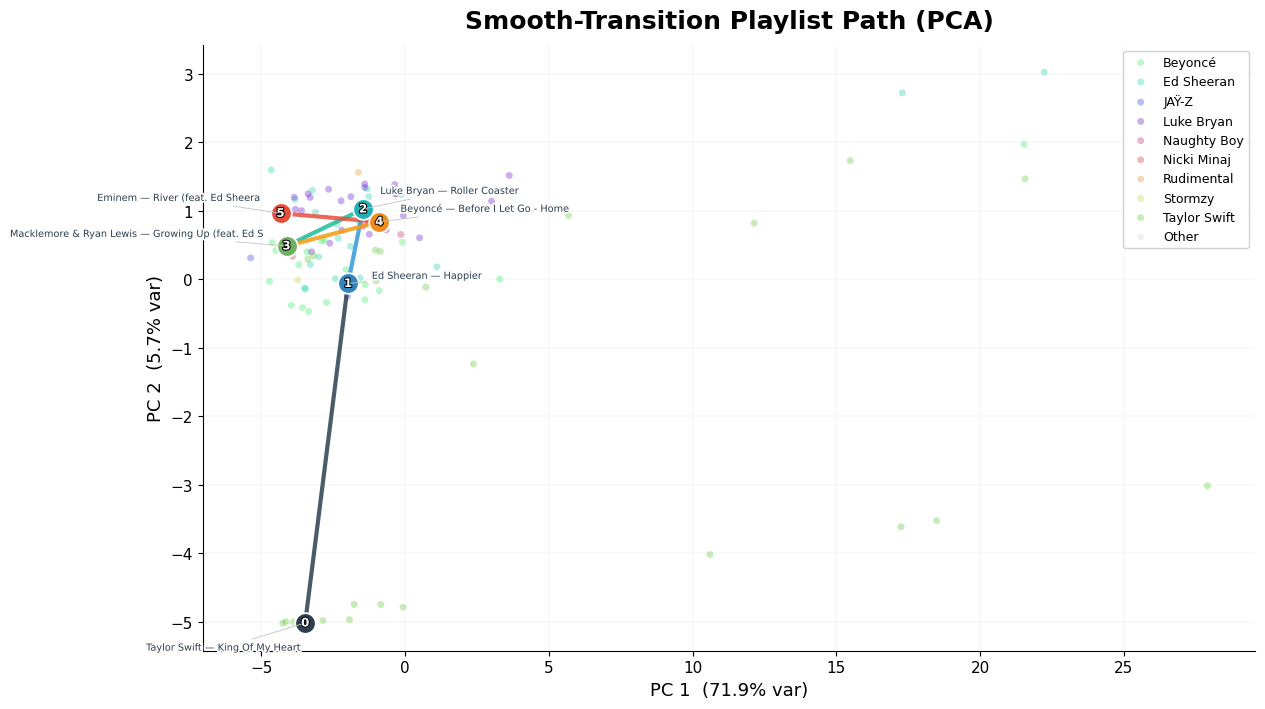

(<Figure size 1280x720 with 1 Axes>,
 <Axes: title={'center': 'Smooth-Transition Playlist Path (PCA)'}, xlabel='PC 1  (71.9% var)', ylabel='PC 2  (5.7% var)'>)

In [82]:
from graphing_graphics import plot_smooth_playlist, primary_artist, _generate_distinct_colors

unique_artists = sorted(set(artist_series.map(primary_artist)))
artist_colors = dict(zip(unique_artists, _generate_distinct_colors(len(unique_artists))))

plot_smooth_playlist(
    merged_features, playlist, artist_series, song_name_series,
    artist_colors=artist_colors,
)

# The thematic playlist

Similar to the last playlist, we're making a playlist using shortest euclidean distances. Instead we'll use a simple k means clustering approch to divide the songs into groups of similar songs and then picks one central song from each cluster.

1. Use k means clustering to divide the songs into groups of similar songs.
    Why did I pick k=6? Since the playlist needs to be 6 songs long, we need exactly 6 songs for the playlist. Using 6 clusters means each cluster contributes one song, guaranteeing the playlist spans the every possible thematic region of the dataset.
2. From each cluster, I score each song based on how close it is to the cluster's centroid (weighted at 60%) and bridge quality (how close it is to other clusters' centroids). This means that every song I pick is both representative of its cluster and a good transition point to other clusters.
3. I then order the playlist of the 6 representatives using greedy nearest neighbors.
4. Copied the post-refinement and forward vs reversed steps from the last playlist generation method.

In [83]:
thematic_k = 6
thematic_clusters, thematic_km = kmeans_cluster(merged_features, n_clusters=thematic_k)

print(f"Cluster sizes:")
for cid in range(thematic_k):
    members = thematic_clusters[thematic_clusters == cid].index
    artists_in = artist_series[members].value_counts()
    print(f"  Cluster {cid}: {len(members)} songs")

Cluster sizes:
  Cluster 0: 32 songs
  Cluster 1: 6 songs
  Cluster 2: 9 songs
  Cluster 3: 4 songs
  Cluster 4: 40 songs
  Cluster 5: 9 songs


# Question 2's solution
The thematic playlist using k means clustering

In [84]:
filled = merged_features.fillna(merged_features.median())
centroids = thematic_km.cluster_centers_

representatives = []

for cid in range(thematic_k):
    members = thematic_clusters[thematic_clusters == cid].index.tolist()

    scores = []
    for sid in members:
        d_own = np.linalg.norm(filled.loc[sid].values - centroids[cid])
        d_others = [np.linalg.norm(filled.loc[sid].values - centroids[c]) for c in range(thematic_k) if c != cid]
        d_bridge = np.mean(d_others)
        scores.append((sid, d_own, d_bridge))

    own_vals = np.array([s[1] for s in scores])
    bridge_vals = np.array([s[2] for s in scores])
    own_norm = (own_vals - own_vals.min()) / (own_vals.max() - own_vals.min()) if own_vals.max() > own_vals.min() else np.zeros(len(scores))
    bridge_norm = (bridge_vals - bridge_vals.min()) / (bridge_vals.max() - bridge_vals.min()) if bridge_vals.max() > bridge_vals.min() else np.zeros(len(scores))

    combined = 0.6 * own_norm + 0.4 * bridge_norm
    best_idx = np.argmin(combined)
    best_sid = scores[best_idx][0]

    representatives.append(best_sid)


avg_d = dist_playlist.loc[representatives, representatives].mean(axis=1)
current = avg_d.idxmin()
thematic_playlist = [current]
remaining = set(representatives) - {current}

for step in range(1, 6):
    current = thematic_playlist[-1]
    current_artist = artist_series[current]

    diff_artist = [s for s in remaining if artist_series[s] != current_artist]
    pool = diff_artist if diff_artist else list(remaining)
    distances = dist_playlist.loc[current, pool].copy()

    min_dist = distances.min()
    tied = distances[distances == min_dist].index.tolist()
    tied.sort(key=lambda s: song_name_series[s].lower())
    next_song = tied[0]

    thematic_playlist.append(next_song)
    remaining.remove(next_song)

route = list(thematic_playlist)
n = len(route)
improved = True
iters = 0
while improved and iters < 50:
    improved = False
    iters += 1
    for i in range(n - 2):
        for j in range(i + 2, n):
            old_cost = dist_playlist.loc[route[i], route[i + 1]]
            if j + 1 < n:
                old_cost += dist_playlist.loc[route[j], route[j + 1]]
            new_cost = dist_playlist.loc[route[i], route[j]]
            if j + 1 < n:
                new_cost += dist_playlist.loc[route[i + 1], route[j + 1]]
            if new_cost < old_cost - 1e-9:
                candidate = route[:i+1] + route[i+1:j+1][::-1] + route[j+1:]
                artist_ok = all(artist_series[candidate[k]] != artist_series[candidate[k+1]] for k in range(len(candidate)-1))
                if artist_ok:
                    route = candidate
                    improved = True

thematic_playlist = route
fwd_cost = sum(dist_playlist.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in range(len(thematic_playlist)-1))
rev = list(reversed(thematic_playlist))
rev_ok = all(artist_series[rev[k]] != artist_series[rev[k+1]] for k in range(len(rev)-1))
if rev_ok:
    rev_cost = sum(dist_playlist.loc[rev[i], rev[i+1]] for i in range(len(rev)-1))
    if rev_cost < fwd_cost:
        thematic_playlist = rev


features = df_audio_norm.columns.tolist()
rows = []
for i, sid in enumerate(thematic_playlist):
    row = {"Cluster": thematic_clusters[sid],
           "Song": song_name_series[sid], "Artist": artist_series[sid]}
    for f in features:
        row[f] = f"{df_audio_norm.loc[sid, f]:.3f}"
    if i > 0:
        prev = thematic_playlist[i-1]
        row["Flow Dist"] = f"{dist_flow.loc[prev, sid]:.4f}"
        row["Audio Dist"] = f"{dist_audio.loc[prev, sid]:.4f}"
        row["Lyrics Dist"] = f"{dist_lyrics.loc[prev, sid]:.4f}"
        row["Image Dist"] = f"{dist_image.loc[prev, sid]:.4f}"
        row["Merged Dist"] = f"{dist_merged.loc[prev, sid]:.4f}"
        row["Blended Dist"] = f"{dist_playlist.loc[prev, sid]:.4f}"
    else:
        row["Flow Dist"] = "-"
        row["Audio Dist"] = "-"
        row["Lyrics Dist"] = "-"
        row["Image Dist"] = "-"
        row["Merged Dist"] = "-"
        row["Blended Dist"] = "-"
    rows.append(row)

display(pd.DataFrame(rows))

,Cluster,Song,Artist,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,...,mode_confidence,song_duration_ms,popularity,explicit,Flow Dist,Audio Dist,Lyrics Dist,Image Dist,Merged Dist,Blended Dist
0,2,Daylight,['Taylor Swift'],0.931,0.528,0.119,0.773,0.000,1.000,0.167,...,0.625,0.592,0.836,0.000,-,-,-,-,-,-
1,4,"Been There, Done That",['Luke Bryan'],0.204,0.388,0.582,0.626,0.500,0.119,0.989,...,0.688,0.494,0.127,0.000,0.3150,2.1212,4.0363,8.2689,0.5357,0.4595
2,3,Don’t Blame Me,['Taylor Swift'],0.442,0.896,0.856,0.457,0.000,0.908,0.505,...,0.625,0.356,0.873,0.000,0.2519,1.6255,8.4329,9.0591,0.6017,0.4712
3,0,"Sunrise, Sunburn, Sunset",['Luke Bryan'],0.397,0.485,0.677,0.891,0.400,0.499,0.049,...,0.250,0.272,0.473,0.000,0.4977,1.3398,8.8941,8.9267,0.5709,0.5739
4,5,Lift Off,"['JAŸ-Z', 'Kanye West', 'Beyoncé']",0.643,0.358,0.552,0.843,0.900,0.647,0.498,...,0.688,0.480,0.382,1.000,0.1155,1.9179,5.3854,8.6550,0.5509,0.3697
5,1,Delicate,['Taylor Swift'],0.959,0.318,0.060,0.012,0.900,0.818,0.481,...,0.562,0.339,0.855,0.000,0.0407,1.9140,10.7206,8.9184,0.7066,0.4342


# Stats
This are the metrics that I'll use to evaluate the quality of the playlist

In [85]:
consec = list(range(len(thematic_playlist) - 1))
flow_d = [dist_flow.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in consec]
audio_d = [dist_audio.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in consec]
lyrics_d = [dist_lyrics.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in consec]
image_d = [dist_image.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in consec]
merged_d = [dist_merged.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in consec]
blended_d = [dist_playlist.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in consec]

from itertools import combinations
all_pairs_merged = [dist_merged.loc[a, b] for a, b in combinations(thematic_playlist, 2)]

unique_artists = list(set(artist_series[sid] for sid in thematic_playlist))

print(f"Mean distances:")
print(f"  Flow:    {np.mean(flow_d):.4f}  (deviation: {np.std(flow_d):.4f}, max: {max(flow_d):.4f})")
print(f"  Audio:   {np.mean(audio_d):.4f}  (deviation: {np.std(audio_d):.4f})")
print(f"  Lyrics:  {np.mean(lyrics_d):.4f}  (deviation: {np.std(lyrics_d):.4f})")
print(f"  Image:   {np.mean(image_d):.4f}  (deviation: {np.std(image_d):.4f})")
print(f"  Merged:  {np.mean(merged_d):.4f}  (deviation: {np.std(merged_d):.4f})")
print(f"  Blended: {np.mean(blended_d):.4f}  (deviation: {np.std(blended_d):.4f})")
print(f"Semantic spread: {np.mean(all_pairs_merged):.4f}")
print(f"Artist diversity: {len(unique_artists)} unique")

Mean distances:
  Flow:    0.2442  (deviation: 0.1596, max: 0.4977)
  Audio:   1.7837  (deviation: 0.2724)
  Lyrics:  7.4939  (deviation: 2.4354)
  Image:   8.7656  (deviation: 0.2809)
  Merged:  0.5932  (deviation: 0.0608)
  Blended: 0.4617  (deviation: 0.0662)
Semantic spread: 0.6014
Artist diversity: 3 unique


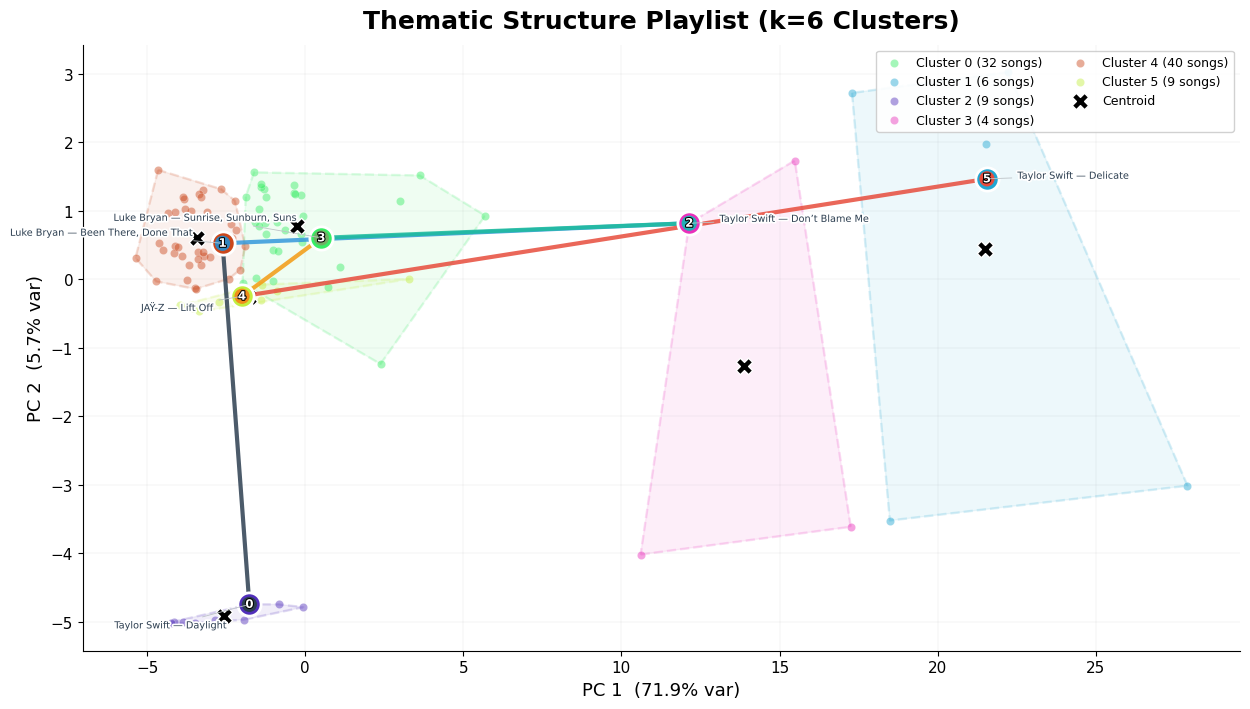

(<Figure size 1280x720 with 1 Axes>,
 <Axes: title={'center': 'Thematic Structure Playlist (k=6 Clusters)'}, xlabel='PC 1  (71.9% var)', ylabel='PC 2  (5.7% var)'>)

In [86]:
from graphing_graphics import plot_thematic_playlist

plot_thematic_playlist(
    merged_features, thematic_playlist, thematic_clusters, thematic_km,
    artist_series, song_name_series,
)

# Alice's Random Playlist (Control)

Ignoring all features and distances and randomly picking songs with rules:

- At least one song from each artist
- 6 songs max

In [87]:
from graphing_graphics import primary_artist

rng = np.random.default_rng(seed=42)

primary = artist_series.map(primary_artist)
major_artists = primary.value_counts().nlargest(4).index.tolist()

alice_picks = []
for artist in major_artists:
    pool = primary[primary == artist].index.tolist()
    alice_picks.append(rng.choice(pool))

remaining_pool = [s for s in primary.index if s not in alice_picks]
extras = rng.choice(remaining_pool, size=2, replace=False)
alice_picks.extend(extras.tolist())

rng.shuffle(alice_picks)
alice_playlist = alice_picks

# Stats
This are the metrics that I'll use to evaluate the quality of the playlist

In [88]:
consec = list(range(len(alice_playlist) - 1))
flow_d = [dist_flow.loc[alice_playlist[i], alice_playlist[i+1]] for i in consec]
audio_d = [dist_audio.loc[alice_playlist[i], alice_playlist[i+1]] for i in consec]
lyrics_d = [dist_lyrics.loc[alice_playlist[i], alice_playlist[i+1]] for i in consec]
image_d = [dist_image.loc[alice_playlist[i], alice_playlist[i+1]] for i in consec]
merged_d = [dist_merged.loc[alice_playlist[i], alice_playlist[i+1]] for i in consec]
blended_d = [dist_playlist.loc[alice_playlist[i], alice_playlist[i+1]] for i in consec]

from itertools import combinations
all_pairs_merged = [dist_merged.loc[a, b] for a, b in combinations(alice_playlist, 2)]

unique_artists = list(set(artist_series[sid] for sid in alice_playlist))

print(f"Mean distances:")
print(f"  Flow:    {np.mean(flow_d):.4f}  (deviation: {np.std(flow_d):.4f}, max: {max(flow_d):.4f})")
print(f"  Audio:   {np.mean(audio_d):.4f}  (deviation: {np.std(audio_d):.4f})")
print(f"  Lyrics:  {np.mean(lyrics_d):.4f}  (deviation: {np.std(lyrics_d):.4f})")
print(f"  Image:   {np.mean(image_d):.4f}  (deviation: {np.std(image_d):.4f})")
print(f"  Merged:  {np.mean(merged_d):.4f}  (deviation: {np.std(merged_d):.4f})")
print(f"  Blended: {np.mean(blended_d):.4f}  (deviation: {np.std(blended_d):.4f})")
print(f"Semantic spread: {np.mean(all_pairs_merged):.4f}")
print(f"Artist diversity: {len(unique_artists)} unique")

Mean distances:
  Flow:    0.2789  (deviation: 0.2043, max: 0.5930)
  Audio:   1.9416  (deviation: 0.5918)
  Lyrics:  4.3039  (deviation: 0.9994)
  Image:   8.5764  (deviation: 0.3168)
  Merged:  0.5223  (deviation: 0.0721)
  Blended: 0.4326  (deviation: 0.1459)
Semantic spread: 0.4990
Artist diversity: 4 unique


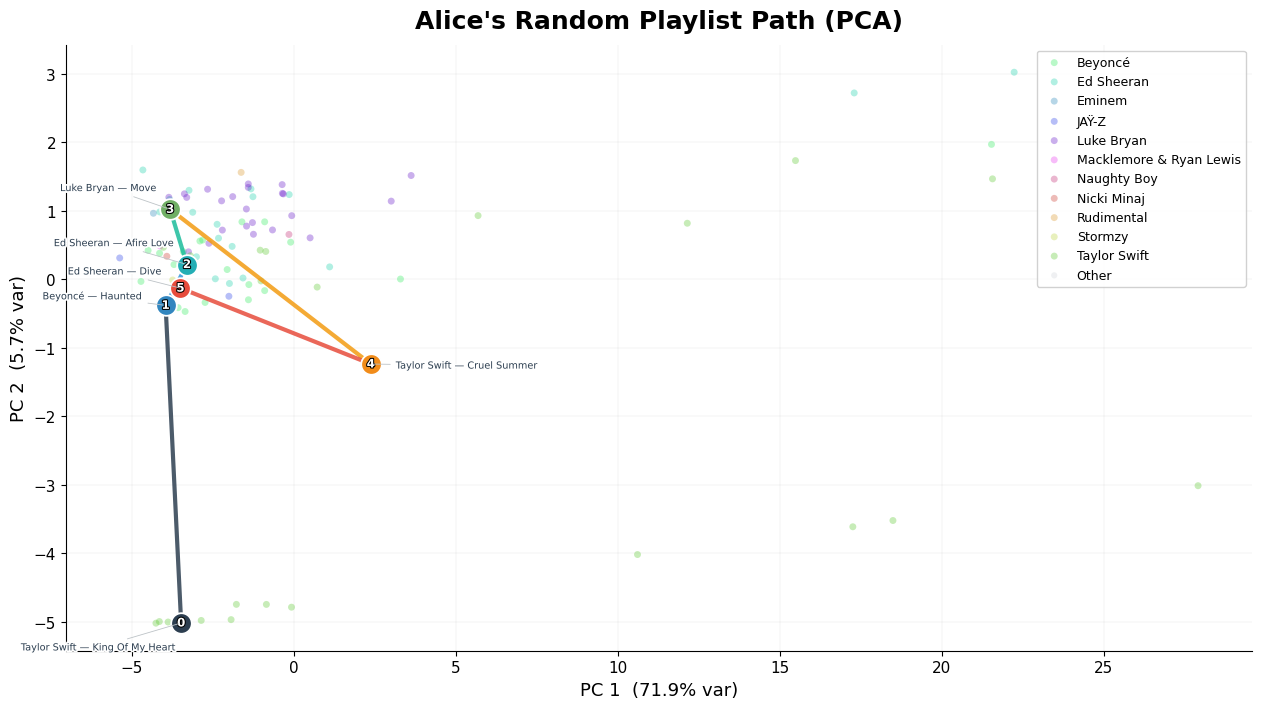

(<Figure size 1280x720 with 1 Axes>,
 <Axes: title={'center': "Alice's Random Playlist Path (PCA)"}, xlabel='PC 1  (71.9% var)', ylabel='PC 2  (5.7% var)'>)

In [89]:
from graphing_graphics import plot_smooth_playlist, primary_artist, _generate_distinct_colors

unique_artists = sorted(set(artist_series.map(primary_artist)))
artist_colors = dict(zip(unique_artists, _generate_distinct_colors(len(unique_artists))))

plot_smooth_playlist(
    merged_features, alice_playlist, artist_series, song_name_series,
    artist_colors=artist_colors,
    title="Alice's Random Playlist Path (PCA)",
    save_path="random_playlist_path.png",
)

In [90]:
s_consec = list(range(len(playlist) - 1))
s_flow = [dist_flow.loc[playlist[i], playlist[i+1]] for i in s_consec]
s_audio = [dist_audio.loc[playlist[i], playlist[i+1]] for i in s_consec]
s_lyrics = [dist_lyrics.loc[playlist[i], playlist[i+1]] for i in s_consec]
s_image = [dist_image.loc[playlist[i], playlist[i+1]] for i in s_consec]
s_merged = [dist_merged.loc[playlist[i], playlist[i+1]] for i in s_consec]
s_blended = [dist_playlist.loc[playlist[i], playlist[i+1]] for i in s_consec]
s_pairs = [dist_merged.loc[a, b] for a, b in combinations(playlist, 2)]
s_artists = list(set(artist_series[sid] for sid in playlist))

t_consec = list(range(len(thematic_playlist) - 1))
t_flow = [dist_flow.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in t_consec]
t_audio = [dist_audio.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in t_consec]
t_lyrics = [dist_lyrics.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in t_consec]
t_image = [dist_image.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in t_consec]
t_merged = [dist_merged.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in t_consec]
t_blended = [dist_playlist.loc[thematic_playlist[i], thematic_playlist[i+1]] for i in t_consec]
t_pairs = [dist_merged.loc[a, b] for a, b in combinations(thematic_playlist, 2)]
t_artists = list(set(artist_series[sid] for sid in thematic_playlist))

a_consec = list(range(len(alice_playlist) - 1))
a_flow = [dist_flow.loc[alice_playlist[i], alice_playlist[i+1]] for i in a_consec]
a_audio = [dist_audio.loc[alice_playlist[i], alice_playlist[i+1]] for i in a_consec]
a_lyrics = [dist_lyrics.loc[alice_playlist[i], alice_playlist[i+1]] for i in a_consec]
a_image = [dist_image.loc[alice_playlist[i], alice_playlist[i+1]] for i in a_consec]
a_merged = [dist_merged.loc[alice_playlist[i], alice_playlist[i+1]] for i in a_consec]
a_blended = [dist_playlist.loc[alice_playlist[i], alice_playlist[i+1]] for i in a_consec]
a_pairs = [dist_merged.loc[a, b] for a, b in combinations(alice_playlist, 2)]
a_artists = list(set(artist_series[sid] for sid in alice_playlist))

comparison = pd.DataFrame({
    "Metric": [
        "Mean Flow Dist", "Max Flow Dist", "Deviation Flow Dist",
        "Mean Audio Dist", "Mean Lyrics Dist", "Mean Image Dist",
        "Mean Merged Dist", "Mean Blended Dist",
        "Semantic Spread", "Unique Artists"
    ],
    "Smooth Transition": [
        f"{np.mean(s_flow):.4f}", f"{max(s_flow):.4f}", f"{np.std(s_flow):.4f}",
        f"{np.mean(s_audio):.4f}", f"{np.mean(s_lyrics):.4f}", f"{np.mean(s_image):.4f}",
        f"{np.mean(s_merged):.4f}", f"{np.mean(s_blended):.4f}",
        f"{np.mean(s_pairs):.4f}", f"{len(s_artists)}"
    ],
    "Thematic Structure": [
        f"{np.mean(t_flow):.4f}", f"{max(t_flow):.4f}", f"{np.std(t_flow):.4f}",
        f"{np.mean(t_audio):.4f}", f"{np.mean(t_lyrics):.4f}", f"{np.mean(t_image):.4f}",
        f"{np.mean(t_merged):.4f}", f"{np.mean(t_blended):.4f}",
        f"{np.mean(t_pairs):.4f}", f"{len(t_artists)}"
    ],
    "Alice's Random": [
        f"{np.mean(a_flow):.4f}", f"{max(a_flow):.4f}", f"{np.std(a_flow):.4f}",
        f"{np.mean(a_audio):.4f}", f"{np.mean(a_lyrics):.4f}", f"{np.mean(a_image):.4f}",
        f"{np.mean(a_merged):.4f}", f"{np.mean(a_blended):.4f}",
        f"{np.mean(a_pairs):.4f}", f"{len(a_artists)}"
    ]
})
display(comparison)

,Metric,Smooth Transition,Thematic Structure,Alice's Random
0,Mean Flow Dist,0.0116,0.2442,0.2789
1,Max Flow Dist,0.0373,0.4977,0.5930
2,Deviation Flow Dist,0.0152,0.1596,0.2043
3,Mean Audio Dist,0.8736,1.7837,1.9416
4,Mean Lyrics Dist,4.2471,7.4939,4.3039
5,Mean Image Dist,9.0599,8.7656,8.5764
6,Mean Merged Dist,0.3730,0.5932,0.5223
7,Mean Blended Dist,0.2012,0.4617,0.4326
8,Semantic Spread,0.4042,0.6014,0.4990
9,Unique Artists,6,3,4
